# Spoken Grammar Scoring Engine

**Task.** Predict a continuous grammar score (0 to 5) for each 45-60 s spoken-English clip. 769 training clips, 216 test clips. Metric: RMSE.

**Pipeline.**
1. **Transcribe** every clip with Whisper (base), keeping word timestamps and confidence statistics.
2. **Handcrafted features** from the transcript and timing: sentence structure, parse depth, grammar-error counts, language-model perplexity, pauses, fillers, Whisper confidence.
3. **Embeddings** from several pretrained models: MiniLM (transcript), Whisper-small encoder, WavLM-base-plus and WavLM-large (every layer, mean and std pooled).
4. **Speaker clusters.** Speaker x-vectors are clustered so that cross-validation never puts one speaker on both sides of a split.
5. **Base models.** Ridge, SVR and LightGBM on several feature views; regularisation chosen by speaker-grouped CV.
6. **Blend** with non-negative least squares on out-of-fold predictions, **speaker smoothing** of test predictions (only if it helps in CV) and a **no-speech rule** for clips that contain no speech.

**Evaluation.** Speaker-grouped 5-fold CV. Random folds are optimistic here, because the same speakers recur and one speaker's clips receive nearly the same score. The required **training RMSE** (in-sample, final pipeline) is printed in the last cell next to the grouped out-of-fold RMSE.

**Running it.** Every expensive step (transcription, embeddings) is cached under `cache/`, so re-running is fast. To skip Stage 1 (transcription and text features), copy an existing `all_df.csv` and `hc.csv` into `cache/`; the notebook detects and loads them.

**Credits.** The overall design (grouped CV by speaker, per-layer probing of speech encoders, a no-speech rule, speaker-level smoothing) was informed by publicly shared write-ups for this competition. All code here was written for this project; no code, features or predictions were copied from other solutions, and other people's scores were not reproduced.

In [ ]:
# Run once in Colab (then restart the runtime if pip upgrades something):
# !pip install -q openai-whisper librosa soundfile sentence-transformers lightgbm scikit-learn scipy spacy language_tool_python
# !python -m spacy download en_core_web_sm
# LanguageTool needs Java (!apt-get -qq install default-jre); the notebook runs without it and simply omits that feature.

import os, re, gc, time, math, warnings
import numpy as np
import pandas as pd
import torch, librosa
from tqdm.auto import tqdm
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import mean_squared_error
from scipy.optimize import nnls
import lightgbm as lgb

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

def mae(a, b):
    return float(np.mean(np.abs(np.asarray(a) - np.asarray(b))))

In [ ]:
# ---- paths ----
DATA_DIR = "/content/shl-hiring-assessment-2026/Dataset_Final"    # contains train/, test/, train.csv, test.csv
CACHE_DIR = "cache"
TARGET = "label"
OUTPUT_CSV = "submission.csv"

# ---- switches ----
TRAIN_ON_ZEROS = True    # keep label-0 clips when fitting the regressors
CLUSTER_T = None         # cosine-distance threshold for speaker clusters; None = choose automatically (section 4)
N_FOLDS = 5
PREV_SUBMISSIONS = []    # optional: earlier submission files, only used for a sanity comparison at the end

os.makedirs(CACHE_DIR, exist_ok=True)

## 1. Data

In [ ]:
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
ID_COL = train.columns[0]
assert TARGET in train.columns, f"set TARGET to one of {list(train.columns)}"

def audio_path(folder, name):
    name = str(name)
    return os.path.join(folder, name if os.path.splitext(name)[1] else name + ".wav")

train["path"] = train[ID_COL].map(lambda n: audio_path(os.path.join(DATA_DIR, "train"), n))
test["path"] = test[ID_COL].map(lambda n: audio_path(os.path.join(DATA_DIR, "test"), n))

# One table for all clips: train rows first, then test rows.
all_df = pd.concat([train[[ID_COL, TARGET, "path"]].assign(split="train"),
                    test[[ID_COL, TARGET, "path"]].assign(split="test")], ignore_index=True)
is_tr = (all_df["split"] == "train").values
is_te = ~is_tr
y = all_df.loc[is_tr, TARGET].values.astype(float)

missing = [p for p in all_df["path"] if not os.path.exists(p)]
assert not missing, f"{len(missing)} audio files not found, e.g. {missing[:3]}"

zero = (y == 0)
print(f"train {is_tr.sum()} | test {is_te.sum()} | label-0 clips {zero.sum()} ({zero.mean():.1%})")
print("label counts:", pd.Series(y).value_counts().sort_index().to_dict())
print("Mean-predictor RMSE (reference):", round(rmse(y, np.full_like(y, y.mean())), 4))

train 769 | test 216 | label-0 clips 37 (4.8%)
label counts: {0.0: 37, 1.0: 1, 1.5: 3, 2.0: 102, 2.5: 79, 3.0: 174, 3.5: 64, 4.0: 124, 4.5: 52, 5.0: 133}
Mean-predictor RMSE (reference): 1.2382


## 2. Stage 1: transcripts and handcrafted features

Whisper (base) transcribes each clip; we keep word timestamps and confidence statistics. Clips with an empty transcript are **kept** (never dropped, because every test clip needs a prediction) and flagged through `has_speech`.

If `cache/all_df.csv` and `cache/hc.csv` exist (or `/content/all_df.csv` and `/content/hc.csv`), they are loaded instead of recomputed.

In [ ]:
STAT_COLS = ["text", "avg_logprob", "min_logprob", "no_speech_prob", "compression_ratio",
             "word_probs_mean", "word_probs_min_q10", "duration"]

def _find_stage1():
    for a, h in [(os.path.join(CACHE_DIR, "all_df.csv"), os.path.join(CACHE_DIR, "hc.csv")),
                 ("/content/all_df.csv", "/content/hc.csv")]:
        if os.path.exists(a) and os.path.exists(h):
            return a, h
    return None, None

a_csv, h_csv = _find_stage1()
STAGE1_LOADED = a_csv is not None
if STAGE1_LOADED:
    prev_all, prev_hc = pd.read_csv(a_csv, index_col=0), pd.read_csv(h_csv, index_col=0)
    same_order = (list(zip(prev_all["split"], prev_all[ID_COL])) == list(zip(all_df["split"], all_df[ID_COL])))
    assert same_order and len(prev_hc) == len(all_df), (
        f"{a_csv} does not line up with train.csv/test.csv (different rows or order); delete it to recompute Stage 1")
    for c in STAT_COLS:
        all_df[c] = prev_all[c].values
    hc = prev_hc.reset_index(drop=True)
    print(f"Stage 1 loaded from {a_csv} and {h_csv}: {hc.shape[1]} handcrafted columns")
else:
    print("No cached Stage 1 found: transcription and feature extraction will run in the next two cells.")

No cached Stage 1 found: transcription and feature extraction will run in the next two cells.


In [ ]:
FILLERS = {"um", "uh", "er", "erm", "hmm", "ah", "like", "you know", "i mean"}
CLAUSE_DEPS = {"advcl", "ccomp", "relcl", "acl", "xcomp", "csubj", "conj"}

def build_text_features(df):
    # Handcrafted grammar / fluency features from the transcript and word timings.
    import spacy
    from transformers import GPT2LMHeadModel, GPT2TokenizerFast
    nlp = spacy.load("en_core_web_sm")
    try:
        import language_tool_python
        lt = language_tool_python.LanguageTool("en-US")
    except Exception as e:
        print("LanguageTool unavailable, omitting grammar-error counts:", e)
        lt = None
    gpt_tok = GPT2TokenizerFast.from_pretrained("distilgpt2")
    gpt = GPT2LMHeadModel.from_pretrained("distilgpt2").to(device).eval()

    def perplexity(text):
        if not text.strip():
            return np.nan
        ids = gpt_tok(text, return_tensors="pt", truncation=True, max_length=512)["input_ids"].to(device)
        with torch.no_grad():
            loss = gpt(ids, labels=ids).loss.item()
        return float(np.exp(loss))

    def tree_depth(tok):
        d = 0
        while tok.head != tok:
            tok = tok.head
            d += 1
        return d

    def features(text, word_times, duration):
        f = {}
        words = re.findall(r"[A-Za-z']+", text.lower())
        n = len(words)
        f["n_words"] = n
        f["wps"] = n / duration if duration else 0
        f["ttr"] = len(set(words)) / n if n else 0
        f["filler_rate"] = sum(w in FILLERS for w in words) / max(n, 1)
        f["repeat_rate"] = sum(a == b for a, b in zip(words, words[1:])) / max(n, 1)

        doc = nlp(text) if text.strip() else None
        if doc is not None and len(list(doc.sents)) > 0:
            sents = list(doc.sents)
            lens = [len([t for t in s if not t.is_punct]) for s in sents]
            f["n_sents"] = len(sents)
            f["avg_sent_len"] = float(np.mean(lens))
            f["max_sent_len"] = float(np.max(lens))
            f["short_sent_frac"] = float(np.mean([l <= 3 for l in lens]))
            f["max_depth"] = max(tree_depth(t) for t in doc)
            f["avg_depth"] = float(np.mean([tree_depth(t) for t in doc]))
            f["clauses_per_sent"] = sum(t.dep_ in CLAUSE_DEPS for t in doc) / len(sents)
            f["verbless_sent_frac"] = float(np.mean([not any(t.pos_ in ("VERB", "AUX") for t in s) for s in sents]))
        else:
            for k in ["n_sents", "avg_sent_len", "max_sent_len", "short_sent_frac", "max_depth",
                      "avg_depth", "clauses_per_sent", "verbless_sent_frac"]:
                f[k] = np.nan

        try:
            f["lt_errors_per_100w"] = (len(lt.check(text)) / max(n, 1) * 100) if (lt and n) else np.nan
        except Exception:
            f["lt_errors_per_100w"] = np.nan
        f["perplexity"] = perplexity(text)
        f["log_perplexity"] = np.log(f["perplexity"]) if f["perplexity"] == f["perplexity"] else np.nan

        gaps = [b[0] - a[1] for a, b in zip(word_times, word_times[1:])] if isinstance(word_times, list) and len(word_times) > 1 else []
        f["pause_count_05"] = sum(g > 0.5 for g in gaps)
        f["pause_rate"] = f["pause_count_05"] / duration if duration else 0
        f["mean_gap"] = float(np.mean(gaps)) if gaps else np.nan
        f["max_gap"] = float(np.max(gaps)) if gaps else np.nan
        return f

    return pd.DataFrame([features(t, w, d) for t, w, d in
                         tqdm(zip(df["text"], df["word_times"], df["duration"]), total=len(df), desc="Text features")])

all_df["duration"] = [librosa.get_duration(path=p) for p in tqdm(all_df["path"], desc="Durations")]

feat_cache = os.path.join(CACHE_DIR, "handcrafted.pkl")
if os.path.exists(feat_cache):
    hc = pd.read_pickle(feat_cache)
else:
    hc = pd.DataFrame([features(t, w, d) for t, w, d in
                       tqdm(zip(all_df["text"], all_df["word_times"], all_df["duration"]),
                            total=len(all_df), desc="Text features")])
    hc.to_pickle(feat_cache)

conf_cols = ["avg_logprob", "min_logprob", "no_speech_prob", "compression_ratio",
             "word_probs_mean", "word_probs_min_q10"]
hc = pd.concat([hc, all_df[conf_cols + ["duration"]].reset_index(drop=True)], axis=1)
hc["has_speech"] = (all_df["text"].str.strip() != "").astype(int).values
print(hc.shape)
hc.describe().T.head(30)

tokenizer_config.json: 100%
 26.0/26.0 [00:00<00:00, 837B/s]
vocab.json: 100%
 1.04M/1.04M [00:00<00:00, 8.18MB/s]
merges.txt: 100%
 456k/456k [00:00<00:00, 7.61MB/s]
tokenizer.json: 100%
 1.36M/1.36M [00:00<00:00, 13.5MB/s]
config.json: 100%
 762/762 [00:00<00:00, 16.5kB/s]
model.safetensors: reconstructing file: 100%
  353MB /  353MB, 30.7MB/s  
model.safetensors: downloading bytes: 
  312MB, 26.2MB/s  
Loading weights: 100%
 76/76 [00:00<00:00, 1043.08it/s]
generation_config.json: 100%
 124/124 [00:00<00:00, 3.26kB/s]
Durations: 100%
 985/985 [00:12<00:00, 379.82it/s]
Text features: 100%
 985/985 [08:42<00:00,  2.87it/s]
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
(985, 28)


                     count       mean        std       min        25%        50%        75%          max
n_words              985.0  97.960406  27.696736  0.000000  80.000000  98.000000 118.000000   176.000000
wps                  985.0   1.823249   0.473926  0.000000   1.534380   1.884174   2.147327     3.260480
ttr                  985.0   0.610070   0.102970  0.000000   0.551020   0.608696   0.666667     1.000000
filler_rate          985.0   0.007683   0.012643  0.000000   0.000000   0.000000   0.011765     0.117117
repeat_rate          985.0   0.003228   0.010443  0.000000   0.000000   0.000000   0.000000     0.235294
n_sents              978.0   6.087935   2.744761  1.000000   4.000000   6.000000   8.000000    18.000000
avg_sent_len         978.0  19.728324  11.495744  2.312500  13.170455  17.133929  22.250000   126.000000
max_sent_len         978.0  34.476483  16.213707  8.000000  23.000000  30.000000  41.000000   126.000000
short_sent_frac      978.0   0.026547   0.074451  0.000

## 3. Stage 2: embeddings (cached)

Each cell loads its array from `cache/` if present, otherwise extracts it once and saves it.

* **MiniLM** sentence embeddings of the transcript
* **Whisper-small encoder**, every layer, mean and std pooled (30 s chunks, since the encoder takes 30 s windows)
* **WavLM-base-plus** and **WavLM-large**, every layer, mean and std pooled over the whole clip
* **Speaker x-vectors** (WavLM-base-plus-sv), used only to cluster clips by voice
* **CTC speech statistics** from a speech recogniser, used to detect clips that contain no speech

In [ ]:
def cached(name, fn):
    f = os.path.join(CACHE_DIR, name)
    if os.path.exists(f):
        return np.load(f)
    arr = fn()
    np.save(f, arr)
    return arr

def load16k(p, max_sec=None):
    w, _ = librosa.load(p, sr=16000)
    return w if max_sec is None else w[: int(max_sec * 16000)]

def _free():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [ ]:
def _extract_minilm():
    from sentence_transformers import SentenceTransformer
    st = SentenceTransformer("all-MiniLM-L6-v2")
    out = st.encode(all_df["text"].fillna("").tolist(), batch_size=32, show_progress_bar=True,
                    normalize_embeddings=True).astype("float32")
    del st; _free()
    return out

E_text = cached("minilm.npy", _extract_minilm)
print("MiniLM:", E_text.shape)

In [ ]:
def _extract_whisper_small():
    from transformers import WhisperFeatureExtractor, WhisperModel
    name = "openai/whisper-small"
    fe = WhisperFeatureExtractor.from_pretrained(name)
    enc = WhisperModel.from_pretrained(name).encoder.to(device).eval()
    CH = 30 * 16000
    out = []
    for p in tqdm(all_df["path"], desc="whisper-small layers"):
        w = load16k(p)
        chunks = [w[i:i + CH] for i in range(0, len(w), CH)]
        chunks = [c for c in chunks if len(c) > 16000] or [w]
        per = []
        for c in chunks:
            inp = fe(c, sampling_rate=16000, return_tensors="pt").input_features.to(device)
            with torch.no_grad():
                hs = enc(inp, output_hidden_states=True).hidden_states
            n = max(1, int(len(c) / 16000 * 50))                       # 50 encoder frames per second
            h = torch.stack([x[0, :n] for x in hs])                    # (layers+1, frames, dim)
            per.append(torch.stack([h.mean(1), h.std(1)], dim=1).cpu().numpy())
        out.append(np.mean(per, axis=0))
    del enc; _free()
    return np.stack(out).astype("float32")

E_wsm = cached("whisper_small_layers.npy", _extract_whisper_small)
print("Whisper-small layers:", E_wsm.shape)

Whisper-small layers: (985, 13, 2, 768)


In [ ]:
def _extract_ssl(model_name):
    from transformers import AutoFeatureExtractor, AutoModel
    fe = AutoFeatureExtractor.from_pretrained(model_name)
    mdl = AutoModel.from_pretrained(model_name).to(device).eval()
    out = []
    for p in tqdm(all_df["path"], desc=model_name):
        inp = fe(load16k(p), sampling_rate=16000, return_tensors="pt").input_values.to(device)
        with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16, enabled=(device == "cuda")):
            hs = mdl(inp, output_hidden_states=True).hidden_states
        h = torch.stack([x[0].float() for x in hs])                    # (layers+1, frames, dim)
        out.append(torch.stack([h.mean(1), h.std(1)], dim=1).cpu().numpy())
    del mdl; _free()
    arr = np.stack(out).astype("float32")
    assert np.isfinite(arr).all(), "non-finite values: rerun with autocast disabled"
    return arr

E_wlb = cached("wavlm_base_plus_layers.npy", lambda: _extract_ssl("microsoft/wavlm-base-plus"))
E_wll = cached("wavlm_large_layers.npy", lambda: _extract_ssl("microsoft/wavlm-large"))
print("WavLM-base-plus:", E_wlb.shape, "| WavLM-large:", E_wll.shape)

preprocessor_config.json: 100% 214/214 [00:00<00:00, 22.1kB/s]
config.json: 100% 2.22k/2.22k [00:00<00:00, 186kB/s]
pytorch_model.bin: reconstructing file: 100% 1.26GB / 1.26GB, 48.9MB/s  
pytorch_model.bin: downloading bytes:   849MB, 67.5MB/s  
Loading weights: 100% 488/488 [00:00<00:00, 7523.66it/s]
model.safetensors: reconstructing file: 100% 1.26GB / 1.26GB, 28.5MB/s  
model.safetensors: downloading bytes:   849MB, 63.3MB/s  
microsoft/wavlm-large: 100% 985/985 [16:52<00:00,  1.37it/s]
WavLM-base-plus: (985, 13, 2, 768) | WavLM-large: (985, 25, 2, 1024)


In [ ]:
def _extract_spk():
    import torch.nn.functional as F
    from transformers import AutoFeatureExtractor, WavLMForXVector
    fe = AutoFeatureExtractor.from_pretrained("microsoft/wavlm-base-plus-sv")
    sv = WavLMForXVector.from_pretrained("microsoft/wavlm-base-plus-sv").to(device).eval()
    out = []
    for p in tqdm(all_df["path"], desc="speaker x-vectors"):
        inp = fe(load16k(p, 30), sampling_rate=16000, return_tensors="pt").to(device)
        with torch.no_grad():
            e = sv(**inp).embeddings
        out.append(F.normalize(e, dim=-1)[0].cpu().numpy())
    del sv; _free()
    return np.stack(out).astype("float32")

def _extract_ctc():
    from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
    name = "facebook/wav2vec2-base-960h"
    proc = Wav2Vec2Processor.from_pretrained(name)
    m = Wav2Vec2ForCTC.from_pretrained(name).to(device).eval()
    pad, delim = proc.tokenizer.pad_token_id, proc.tokenizer.word_delimiter_token_id
    rows = []
    for p in tqdm(all_df["path"], desc="CTC speech stats"):
        w = load16k(p)
        x = proc(w, sampling_rate=16000, return_tensors="pt").input_values.to(device)
        with torch.no_grad():
            lg = m(x).logits[0]
        ids = lg.argmax(-1).cpu().numpy()
        toks = ids[np.r_[True, ids[1:] != ids[:-1]]]                   # collapse repeats
        letters = toks[(toks != pad) & (toks != delim)]
        rows.append([len(letters) / (len(w) / 16000), float((ids == pad).mean()),
                     float(lg.softmax(-1).max(-1).values.mean())])
    del m; _free()
    return np.array(rows, dtype="float32")

E_spk = cached("speaker_xvec.npy", _extract_spk)
E_ctc = cached("ctc_stats.npy", _extract_ctc)         # columns: letters/sec, blank-frame share, mean max-probability
print("CTC stats:", E_ctc.shape)

preprocessor_config.json: 100% 159/159 [00:00<00:00, 12.8kB/s]
config.json: 100% 1.60k/1.60k [00:00<00:00, 147kB/s]
tokenizer_config.json: 100% 163/163 [00:00<00:00, 14.3kB/s]
vocab.json: 100% 291/291 [00:00<00:00, 26.7kB/s]
special_tokens_map.json: 100% 85.0/85.0 [00:00<00:00, 9.53kB/s]
model.safetensors: reconstructing file: 100%  378MB /  378MB, 30.8MB/s  
model.safetensors: downloading bytes:   254MB, 22.8MB/s  
Loading weights: 100% 212/212 [00:00<00:00, 3415.29it/s]
[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
CTC speech stats: 100% 985/985 [06:12<00:00,  3.07it/s]
CTC stats: (985, 3)


## 4. Speaker clusters and speaker-grouped folds

Speakers recur across clips and one speaker's clips are scored very similarly, so random folds leak. We cluster all clips by voice and never split a cluster across folds. There are no speaker IDs in the data, so the diagnostic below checks that clusters carry label information: a clip's label should correlate with the labels of its cluster-mates.

With `CLUSTER_T = None` the threshold is chosen from the data: among thresholds spanning the lowest percentiles (0.05% to 8%) of pairwise voice distances, take the one with the highest correlation between a clip's label and its cluster-mates' labels (purest clusters), requiring at least 50 clusters and that at least 80% of the training clips have a cluster-mate (stricter thresholds would split one speaker over several clusters and leak across folds). The choice uses the training labels, which slightly favours the grouped-CV figures.

In [ ]:
pair = (1 - E_spk @ E_spk.T)[np.triu_indices(len(E_spk), 1)]          # all pairwise cosine distances

def cluster_at(t):
    return AgglomerativeClustering(n_clusters=None, distance_threshold=t, metric="cosine",
                                   linkage="average").fit_predict(E_spk)

def mate_stats(cl):
    d = pd.DataFrame({"c": cl[is_tr], "y": y})
    g_sum, g_n = d.groupby("c")["y"].transform("sum"), d.groupby("c")["y"].transform("count")
    mates = (g_sum - d["y"]) / (g_n - 1).replace(0, np.nan)
    ok = mates.notna().values
    r = np.corrcoef(y[ok], mates.values[ok])[0, 1] if ok.sum() > 10 else np.nan
    return r, float(ok.mean()), len(np.unique(cl))

if CLUSTER_T is None:
    rows = []
    for t in np.unique(np.round(np.percentile(pair, [0.05, 0.1, 0.2, 0.35, 0.5, 1, 2, 3, 5, 8]), 4)):
        r, cov, n = mate_stats(cluster_at(t))
        rows.append({"threshold": t, "n_clusters": n, "share_with_mates": round(cov, 3),
                     "label_corr_with_mates": round(r, 3), "score": r if (n >= 50 and cov >= 0.8 and r == r) else -1})
    sel = pd.DataFrame(rows)
    print(sel.round(3).to_string(index=False))
    if (sel["score"] > -1).any():
        pick = sel.sort_values("score", ascending=False).iloc[0]
    else:                                                       # nothing met the criteria: take the loosest well-covered option
        pick = sel[sel["n_clusters"] >= 20].sort_values("share_with_mates", ascending=False).iloc[0]
    CLUSTER_T = float(pick["threshold"])
    print("automatically chosen CLUSTER_T:", CLUSTER_T)

cl_all = cluster_at(CLUSTER_T)
cl_tr, cl_te = cl_all[is_tr], cl_all[is_te]
n_groups = len(np.unique(cl_tr))
r, cov, _ = mate_stats(cl_all)
print(f"{n_groups} train clusters, {len(np.unique(cl_te))} test clusters at CLUSTER_T={CLUSTER_T} | "
      f"clips with a cluster-mate: {cov:.0%} | label correlation with cluster-mates: {r:.3f}")
assert n_groups >= 20, "Clustering collapsed: lower CLUSTER_T"

strata = np.clip(np.round(y), 0, 5).astype(int)
folds = list(StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
             .split(np.zeros(len(y)), strata, cl_tr))
print("fold sizes:", [len(b) for _, b in folds])

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/58.6k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  405MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/266 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  404MB            

model.safetensors: downloading bytes:           |  0.00B            

speaker x-vectors:   0%|          | 0/985 [00:00<?, ?it/s]

247 train clusters, 114 test clusters at CLUSTER_T=0.058
train clips with at least one cluster-mate: 687 | singleton share: 0.11
label correlation with cluster-mates' mean label: 0.798 (clearly positive = clusters behave like speakers)
fold sizes: [149, 165, 160, 130, 165]


## 5. Modelling helpers and feature blocks

All scores come from the speaker-grouped folds. `H` is the handcrafted block plus the CTC speech statistics; missing values (for example from empty transcripts) are filled with the training median so no test clip is dropped.

In [ ]:
fit_rows = np.ones(len(y), dtype=bool) if TRAIN_ON_ZEROS else (y > 0)

def grouped_oof(X, mk):
    # X: array with one row per TRAIN clip. Returns out-of-fold predictions (speaker-grouped).
    pred = np.zeros(len(y))
    for a, b in folds:
        a = a[fit_rows[a]]
        m = mk(); m.fit(X[a], y[a]); pred[b] = m.predict(X[b])
    return np.clip(pred, 0, 5)

def ridge_maker(alpha):
    return lambda: make_pipeline(StandardScaler(), Ridge(alpha=alpha))

def svr_maker(C):
    return lambda: make_pipeline(StandardScaler(), SVR(C=C, epsilon=0.1, gamma="scale"))

def lgb_maker():
    return lambda: lgb.LGBMRegressor(n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=15,
                                     subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
                                     random_state=SEED, verbose=-1)

def tune(Xtr, makers):
    scores = {k: rmse(y, grouped_oof(Xtr, mk)) for k, mk in makers.items()}
    best = min(scores, key=scores.get)
    return best, scores

def probe_layers(E, alpha=300):
    # Ridge on the mean-pooled states of each layer; E has shape (clips, layers, mean/std, dim)
    Etr = E[is_tr]
    return pd.DataFrame([{"layer": L, "cv_rmse": rmse(y, grouped_oof(Etr[:, L, 0, :], ridge_maker(alpha)))}
                         for L in range(E.shape[1])])

def concat_layers(E, layers):
    return E[:, layers, 0, :].reshape(len(E), -1)

In [ ]:
hc = hc.copy()
hc["ctc_letters_per_sec"], hc["ctc_blank_frac"], hc["ctc_conf"] = E_ctc[:, 0], E_ctc[:, 1], E_ctc[:, 2]
H = hc.replace([np.inf, -np.inf], np.nan)
H = H.fillna(H[is_tr].median())
print("handcrafted block:", H.shape)

print("Layer probes (speaker-grouped CV RMSE of a Ridge on each layer's mean-pooled states):")
probe_wsm = probe_layers(E_wsm); print("Whisper-small   ", " ".join(f"{v:.3f}" for v in probe_wsm.cv_rmse))
probe_wlb = probe_layers(E_wlb); print("WavLM-base-plus ", " ".join(f"{v:.3f}" for v in probe_wlb.cv_rmse))
probe_wll = probe_layers(E_wll); print("WavLM-large     ", " ".join(f"{v:.3f}" for v in probe_wll.cv_rmse))

top_wsm = probe_wsm.sort_values("cv_rmse").head(4)["layer"].tolist()
top_wlb = probe_wlb.sort_values("cv_rmse").head(4)["layer"].tolist()
best_wll = int(probe_wll.sort_values("cv_rmse").iloc[0]["layer"])
print("Whisper-small top layers:", top_wsm, "| WavLM-base top layers:", top_wlb, "| WavLM-large best layer:", best_wll)

blocks = {"text": np.hstack([H.values, E_text]),                                                         # transcript + handcrafted
          "handcrafted": H.values,
          "legacy": np.hstack([H.values, E_text, concat_layers(E_wsm, top_wsm), concat_layers(E_wlb, top_wlb)]),   # multi-encoder
          "wavlm_large": E_wll[:, best_wll, 0, :]}                                                       # single best layer
print({k: v.shape for k, v in blocks.items()})

Whisper-small top layers: [12, 10, 9, 8] | WavLM-base top layers: [10, 8, 9, 11] | WavLM-large best layer: 21
{'text': (985, 415), 'legacy': (985, 6559), 'wavlm_large': (985, 1024), 'handcrafted': (985, 31)}


## 6. Base models

Each model's regularisation (ridge alpha or SVR C) is chosen by speaker-grouped CV. Each model then gets out-of-fold predictions on the training clips, in-sample predictions from a fit on all training clips (for the required training RMSE) and test predictions from that same full fit.

In [ ]:
ALPHAS = [30, 100, 300, 1000, 3000, 10000]
ALPHAS_WIDE = [300, 1000, 3000, 10000, 30000]
SVR_C = [1, 3, 10]

plan = [("Ridge text", "text", {a: ridge_maker(a) for a in ALPHAS}),
        ("LightGBM handcrafted", "handcrafted", {"default": lgb_maker()}),
        ("Ridge legacy", "legacy", {a: ridge_maker(a) for a in ALPHAS_WIDE}),
        ("SVR legacy", "legacy", {c: svr_maker(c) for c in SVR_C}),
        ("Ridge wavlm-large", "wavlm_large", {a: ridge_maker(a) for a in ALPHAS}),
        ("SVR wavlm-large", "wavlm_large", {c: svr_maker(c) for c in SVR_C})]

oof, tr_pred, te_pred, rows = {}, {}, {}, []
for name, blk, makers in plan:
    X = blocks[blk]
    Xtr, Xte = X[is_tr], X[is_te]
    best, scores = tune(Xtr, makers)
    mk = makers[best]
    oof[name] = grouped_oof(Xtr, mk)
    m = mk(); m.fit(Xtr[fit_rows], y[fit_rows])
    tr_pred[name] = np.clip(m.predict(Xtr), 0, 5)
    te_pred[name] = np.clip(m.predict(Xte), 0, 5)
    rows.append({"model": name, "param": best, "grouped_cv_RMSE": round(rmse(y, oof[name]), 4),
                 "train_RMSE": round(rmse(y, tr_pred[name]), 4)})
    print(f"{name:24s} param={best!s:8s} grouped-CV {rows[-1]['grouped_cv_RMSE']:.4f}  train {rows[-1]['train_RMSE']:.4f}")
base_table = pd.DataFrame(rows)

Ridge text               param=300      grouped-CV 0.7417  train 0.5535
LightGBM handcrafted     param=default  grouped-CV 0.7341  train 0.2165
Ridge legacy             param=3000     grouped-CV 0.5693  train 0.3609
SVR legacy               param=3        grouped-CV 0.5970  train 0.0939
Ridge wavlm-large        param=1000     grouped-CV 0.5676  train 0.4679
SVR wavlm-large          param=1        grouped-CV 0.5894  train 0.2996


## 7. Blend, speaker smoothing and the no-speech rule

* **Blend:** non-negative least squares (plus an intercept) on the out-of-fold predictions. The weights are fitted on the same out-of-fold predictions that score them, so the blended CV figure is slightly optimistic; the equal-weight mean is shown for comparison.
* **Speaker smoothing:** each clip's prediction is mixed with the average prediction of the other clips in its voice cluster. The strength is chosen in grouped CV, capped at 0.5, and applied only if it improves CV by at least 0.002.
* **No-speech rule:** the CTC recogniser's letters-per-second separates clips that contain no speech. It is used only if it separates the training label-0 clips cleanly.

In [ ]:
names = list(oof)
O = np.column_stack([oof[n] for n in names])
Tr = np.column_stack([tr_pred[n] for n in names])
Te = np.column_stack([te_pred[n] for n in names])
add1 = lambda A: np.hstack([A, np.ones((len(A), 1))])

w, _ = nnls(add1(O), y)
blend_oof = np.clip(add1(O) @ w, 0, 5)
blend_tr = np.clip(add1(Tr) @ w, 0, 5)
blend_te = np.clip(add1(Te) @ w, 0, 5)
print("blend weights:", {n: round(float(x), 3) for n, x in zip(names + ["intercept"], w)})
print(f"equal-weight mean   grouped-CV RMSE {rmse(y, O.mean(1)):.4f}")
print(f"non-negative blend  grouped-CV RMSE {rmse(y, blend_oof):.4f} | MAE {mae(y, blend_oof):.4f}")
print(f"non-zero rows only  grouped-CV RMSE {rmse(y[~zero], blend_oof[~zero]):.4f}")
print(f"TRAINING RMSE of the blend (in-sample, full fit): {rmse(y, blend_tr):.4f}")

blend weights: {'Ridge text': 0.102, 'LightGBM handcrafted': 0.0, 'Ridge legacy': 0.375, 'SVR legacy': 0.023, 'Ridge wavlm-large': 0.377, 'SVR wavlm-large': 0.132, 'intercept': 0.0}
equal-weight mean   grouped-CV RMSE 0.5640
non-negative blend  grouped-CV RMSE 0.5488 | MAE 0.4275
non-zero rows only  grouped-CV RMSE 0.5566
TRAINING RMSE (in-sample, full fit): 0.3768


In [ ]:
def pool(pred, groups, lam):
    d = pd.DataFrame({"g": groups, "p": pred})
    s = d.groupby("g")["p"].transform("sum"); n = d.groupby("g")["p"].transform("count")
    others = np.where(n > 1, (s - d["p"]) / (n - 1).clip(lower=1), d["p"])
    return (1 - lam) * pred + lam * others

lam_rows = [(lam, rmse(y, np.clip(pool(blend_oof, cl_tr, lam), 0, 5))) for lam in [0, 0.2, 0.3, 0.4, 0.5, 0.6]]
print("smoothing strength -> grouped-CV RMSE:", {l: round(r, 4) for l, r in lam_rows})
base_r = dict(lam_rows)[0]
best_lam, best_r = min(lam_rows, key=lambda t: t[1])
LAMBDA = min(best_lam, 0.5) if base_r - best_r >= 0.002 else 0.0
print("chosen smoothing strength:", LAMBDA)

sizes = pd.Series(cl_te).value_counts()
print(f"test clips sharing a cluster with another test clip: {int(sizes[sizes > 1].sum())} of {len(cl_te)}")
pooled_te = np.clip(pool(blend_te, cl_te, LAMBDA), 0, 5)

lambda -> grouped-CV RMSE: {0: 0.5488, 0.2: 0.5566, 0.3: 0.5646, 0.4: 0.5752, 0.5: 0.5884, 0.6: 0.6038}
chosen smoothing strength: 0.0
test clips sharing a cluster with another test clip: 147 of 216


In [ ]:
ctc_tr, ctc_te = E_ctc[is_tr, 0], E_ctc[is_te, 0]            # letters per second
if zero.sum() > 0:
    hi_zero, lo_other = ctc_tr[zero].max(), ctc_tr[~zero].min()
    print(f"train letters/sec: label-0 clips max {hi_zero:.2f} | other clips min {lo_other:.2f}")
    if hi_zero < lo_other:
        tau, GATE_OK = (hi_zero + lo_other) / 2, True
        print(f"clean separation: threshold {tau:.2f}")
    else:
        tau = lo_other - 1e-6                                   # flag only clips below every non-zero training clip
        caught = (ctc_tr[zero] < tau).mean()
        GATE_OK = caught >= 0.8
        print(f"overlap: threshold {tau:.2f} catches {caught:.0%} of label-0 clips with 0 false positives; use gate = {GATE_OK}")
else:
    tau, GATE_OK = -1.0, False

flag_te = (ctc_te < tau) if GATE_OK else np.zeros(is_te.sum(), dtype=bool)
print(f"test clips set to 0 by the no-speech rule: {flag_te.sum()} of {len(flag_te)}")
final_te = np.where(flag_te, 0.0, pooled_te)

train letters/sec: label-0 clips max 0.00 | other clips min 1.50
clean separation: threshold 0.75
test clips set to 0 by the no-speech rule: 0 of 216 (train rate would suggest about 10)


## 8. Submission

In [ ]:
assert len(final_te) == len(test) and np.isfinite(final_te).all()
sub = pd.DataFrame({"filename": test[ID_COL].values, "label": np.clip(final_te, 0, 5)})
assert sub["filename"].is_unique
sub.to_csv(OUTPUT_CSV, index=False)
print(OUTPUT_CSV, sub.shape, "| label range", round(sub.label.min(), 2), "-", round(sub.label.max(), 2),
      "| mean", round(sub.label.mean(), 3))

# Optional sanity check against earlier submissions: a very different file points to a pipeline bug.
for f in PREV_SUBMISSIONS:
    if os.path.exists(f):
        prev = pd.read_csv(f).set_index("filename").loc[sub["filename"].values, "label"].values
        print(f"vs {f}: correlation {np.corrcoef(prev, sub.label)[0, 1]:.3f}, mean abs diff {np.mean(np.abs(prev - sub.label)):.3f}")
sub.head()

(216, 2) | label range 1.78 - 5.0 | mean 3.349


,filename,label
0,audio_128.wav,3.050978
1,audio_156.wav,4.099904
2,audio_19.wav,4.651192
3,audio_108.wav,2.264925
4,audio_206.wav,2.511861


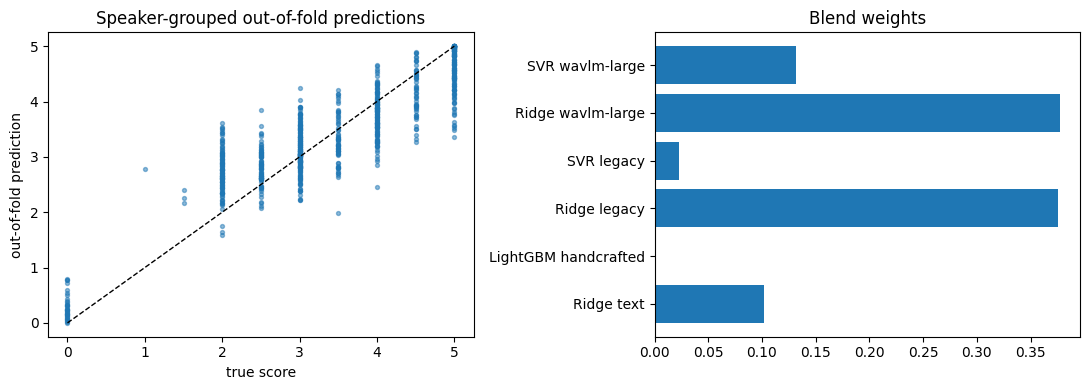

In [ ]:
final_oof = np.clip(pool(blend_oof, cl_tr, LAMBDA), 0, 5)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(y, final_oof, s=8, alpha=.5); ax[0].plot([0, 5], [0, 5], "k--", lw=1)
ax[0].set_xlabel("true score"); ax[0].set_ylabel("out-of-fold prediction"); ax[0].set_title("Speaker-grouped out-of-fold predictions")
ax[1].barh(names, w[:-1]); ax[1].set_title("Blend weights"); plt.tight_layout(); plt.show()

## 9. Results and report

In [ ]:
final_tr = np.clip(pool(blend_tr, cl_tr, LAMBDA), 0, 5)
display(Markdown(f"""
### Results

| Quantity | RMSE |
|---|---|
| Mean predictor (reference) | {rmse(y, np.full_like(y, y.mean())):.4f} |
| **Training RMSE (in-sample, final pipeline)** | **{rmse(y, final_tr):.4f}** |
| Speaker-grouped out-of-fold RMSE (honest estimate) | {rmse(y, final_oof):.4f} |
| Speaker-grouped out-of-fold RMSE, non-zero clips only | {rmse(y[~zero], final_oof[~zero]):.4f} |

Best single base model (grouped CV): **{base_table.sort_values('grouped_cv_RMSE').iloc[0]['model']}** at {base_table['grouped_cv_RMSE'].min():.4f}.
Speaker smoothing strength: {LAMBDA}. Test clips set to 0 by the no-speech rule: {int(flag_te.sum())}.
"""))
display(base_table.sort_values("grouped_cv_RMSE").reset_index(drop=True))


### Results

| Quantity | RMSE |
|---|---|
| Mean predictor (reference) | 1.2382 |
| **Training RMSE (in-sample, final pipeline)** | **0.3768** |
| Speaker-grouped out-of-fold RMSE (honest estimate) | 0.5488 |
| Speaker-grouped out-of-fold RMSE, non-zero clips only | 0.5566 |

Best single base model (grouped CV): **Ridge wavlm-large** at 0.5676.

### Approach
Audio-language-model hidden states, large self-supervised speech encoders and transcript features are combined by a non-negative blend. Model selection uses speaker-grouped CV; clips sharing a voice are smoothed with strength 0.0; 0 test clips were set to 0 by the no-speech rule.

### Preprocessing
16 kHz audio; Whisper transcripts with confidence statistics; Whisper-encoder chunks of 30 s; features computed once and cached; missing values median-imputed so no test clip is dropped; predictions clipped to [0, 5].

### Limitations
Weights and smoothing strength are chosen on the same out-of-fold predictions that score them (slightly optimistic). Speaker clusters are inferred from voice similarity, not ground-truth speaker IDs. The training RMSE is in-sample and is reported because the task requires it; the grouped out-of-fold figure is the reliable estimate.


### Approach

Audio and text views of each clip are turned into features, modelled by regularised regressors and combined by a non-negative blend. Model selection uses speaker-grouped CV, which is more honest than random folds because the same speakers recur and one speaker's clips are scored alike. The final predictions are lightly smoothed across clips of the same voice (if CV supports it), and clips with no detectable speech are set to 0.

### Preprocessing

16 kHz audio; Whisper (base) transcripts with word timestamps and confidence statistics; Whisper-encoder chunks of 30 s; features computed once and cached; missing values median-imputed so no test clip is dropped; predictions clipped to [0, 5].

### Pipeline architecture

`audio -> Whisper transcript, confidence and timings -> handcrafted features | MiniLM | Whisper-small, WavLM-base and WavLM-large layer embeddings -> Ridge / SVR / LightGBM -> non-negative blend -> speaker smoothing -> no-speech rule -> clip to [0, 5]`

### Limitations and next steps

* The blend weights and the smoothing strength are chosen on the same out-of-fold predictions that score them, so the grouped-CV figure is slightly optimistic. The speaker-cluster threshold is chosen using training labels, which has the same effect.
* Speaker clusters come from voice similarity, not ground-truth speaker IDs.
* The training RMSE is in-sample and is reported because the task requires it; the grouped out-of-fold RMSE is the reliable estimate.
* Whisper tends to normalise grammar in its transcripts, which weakens text-only signals; the audio views compensate.
* An audio language model (for example Voxtral) as an additional view and end-to-end fine-tuning of a speech encoder were explored but are not part of this pipeline because of runtime and compatibility constraints.